<a href="https://colab.research.google.com/github/WVF-1/Pittsburgh-Traffic-Flow/blob/main/baseline_vs_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Project 3: Baseline Model vs. a Light Graph Neural Network

**Newsletter series: Geospatial Data & Public Transportation — Project 3 of 5 (Modeling)**

Last project modeled where commuter traffic concentrates by routing real commute flows over the road network. This project asks a different question: **can a model learn to predict a road segment's traffic intensity (Low / Medium / High) just from the segment's own structure and its place in the network** -- without us explicitly routing anything?

Two models, same task, same train/test split, so the comparison is fair:

1. **Baseline: Random Forest** on structural features alone (road class, length, travel time, intersection degree) -- no awareness of the network as a network.
2. **A light Graph Neural Network (GNN)** -- a 2-layer Graph Convolutional Network that learns a representation of every *intersection* from its neighbors, then predicts each *road segment's* intensity from its two endpoints.

**Framing note for later:** this is a one-shot prediction task -- the model observes a snapshot and guesses. Project 5's GNN is a different job entirely: coordinating streetlights in a live, sequential simulation. They'll likely share the same graph representation and library, but "predict" and "act" are genuinely different problems -- worth keeping distinct for readers.

**A direct payoff from a question you raised a few weeks back:** road class gets represented here as a small *learned embedding* rather than one-hot or ordinal encoding -- exactly the fix we discussed. By the end, we can literally look at the 2D space the model placed the five road classes in and see what relationships it found on its own.

**Data:** this week's Random Forest features and network structure are freshly pulled from OpenStreetMap (ODbL); labels come from last week's `pittsburgh_road_assigned_flow.csv` export (built from Census LODES data, public domain).

## Setup

In [1]:
!pip install osmnx geopandas contextily -q
!pip install torch_geometric -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder

ox.settings.log_console = False
torch.manual_seed(42)
np.random.seed(42)

PGH_BLACK = "#1a1a1a"
INTENSITY_COLORS = {"Low": "#2e8b57", "Medium": "#f2b134", "High": "#c1440e"}
INTENSITY_ORDER = ["Low", "Medium", "High"]


## Step 1: Re-pull the road network, reattach last week's labels

Same county-wide network as last week (OSM node IDs are stable, so this merges cleanly in almost all cases). We reattach `assigned_flow` and `intensity` from the CSV you exported last time. A small number of segments may not match if OpenStreetMap was edited between the two pulls -- normal, and we have plenty of labeled segments either way.

In [3]:
place = "Allegheny County, Pennsylvania, USA"

G = ox.graph_from_place(place, network_type="drive")
G_proj = ox.project_graph(G)
G_crs = G_proj.graph["crs"]
nodes, edges = ox.graph_to_gdfs(G_proj)
print(f"Nodes: {len(nodes):,}   Edges: {len(edges):,}")


Nodes: 48,435   Edges: 121,006


In [4]:
HIERARCHY_MAP = {
    "motorway": "Highway", "motorway_link": "Highway",
    "trunk": "Highway", "trunk_link": "Highway",
    "primary": "Primary", "primary_link": "Primary",
    "secondary": "Secondary", "secondary_link": "Secondary",
    "tertiary": "Tertiary", "tertiary_link": "Tertiary",
}
SPEED_MPH = {"Highway": 55, "Primary": 35, "Secondary": 30, "Tertiary": 25, "Local": 20}

def classify(row):
    hw = row.get("highway")
    if isinstance(hw, list):
        hw = hw[0]
    return HIERARCHY_MAP.get(hw, "Local")

edges["road_class"] = edges.apply(classify, axis=1)
edges["speed_mps"] = edges["road_class"].map(SPEED_MPH) * 0.44704
edges["travel_time"] = edges["length"] / edges["speed_mps"]

edges_reset = edges.reset_index()
edges_reset[["u", "v", "key"]] = edges_reset[["u", "v", "key"]].astype("int64")


## Upload last week's export

Just `pittsburgh_road_assigned_flow.csv`.

In [5]:
from google.colab import files

uploaded = files.upload()


Saving pittsburgh_road_assigned_flow.csv to pittsburgh_road_assigned_flow.csv


In [6]:
flow_df = pd.read_csv("pittsburgh_road_assigned_flow.csv")
flow_df[["u", "v", "key"]] = flow_df[["u", "v", "key"]].astype("int64")

merged = edges_reset.merge(flow_df[["u", "v", "key", "assigned_flow", "intensity"]], on=["u", "v", "key"], how="left")

n_labeled = merged["intensity"].notna().sum()
print(f"Total edges: {len(merged):,}   Labeled edges: {n_labeled:,}")
merged["intensity"].value_counts(dropna=False)


Total edges: 121,006   Labeled edges: 3,030


,count
intensity,
NaN,117976
High,1020
Medium,1006
Low,1004


## Visual 1: Class balance

The overwhelming majority of segments carry no assigned flow at all (last week only routed the 150 heaviest commuting pairs), and the labeled ones split into three roughly comparable tiers.

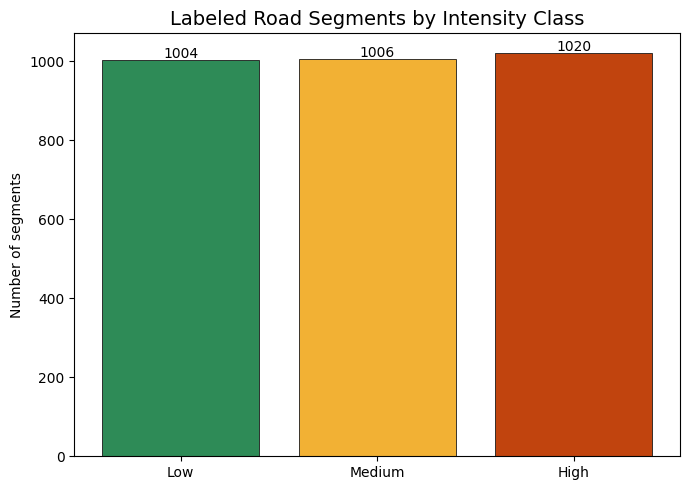

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = merged["intensity"].value_counts().reindex(INTENSITY_ORDER)
ax.bar(counts.index, counts.values, color=[INTENSITY_COLORS[c] for c in counts.index], edgecolor=PGH_BLACK, linewidth=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)

ax.set_title("Labeled Road Segments by Intensity Class", fontsize=14)
ax.set_ylabel("Number of segments")
plt.tight_layout()
plt.savefig("viz1_class_balance.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 2: Build features

Every model gets the same underlying information: road class, length, travel time, and each segment's intersection degree (how many streets meet at each end -- a simple structural feature). The Random Forest sees road class one-hot encoded (no graph awareness at all); the GNN will see it as a learned embedding instead.

In [8]:
# Node index mapping and degree features (used by both models)
node_ids = pd.unique(pd.concat([merged["u"], merged["v"]]))
node_id_map = {nid: i for i, nid in enumerate(node_ids)}

merged["u_idx"] = merged["u"].map(node_id_map)
merged["v_idx"] = merged["v"].map(node_id_map)

out_deg = merged["u_idx"].value_counts()
in_deg = merged["v_idx"].value_counts()

merged["u_out_deg"] = merged["u_idx"].map(out_deg).fillna(0)
merged["u_in_deg"] = merged["u_idx"].map(in_deg).fillna(0)
merged["v_out_deg"] = merged["v_idx"].map(out_deg).fillna(0)
merged["v_in_deg"] = merged["v_idx"].map(in_deg).fillna(0)

labeled = merged[merged["intensity"].notna()].copy()
print(f"Working with {len(labeled):,} labeled segments")


Working with 3,030 labeled segments


In [9]:
# One train/test split, reused identically for both models so the comparison is fair
train_idx, test_idx = train_test_split(
    labeled.index, test_size=0.3, stratify=labeled["intensity"], random_state=42
)

label_map = {"Low": 0, "Medium": 1, "High": 2}
labeled["label"] = labeled["intensity"].map(label_map)

print(f"Train: {len(train_idx)}   Test: {len(test_idx)}")


Train: 2121   Test: 909


## Step 3: Baseline — Random Forest on structural features

In [10]:
rf_features = ["length", "travel_time", "u_out_deg", "u_in_deg", "v_out_deg", "v_in_deg"]

encoder = OneHotEncoder(sparse_output=False)
class_ohe = encoder.fit_transform(labeled[["road_class"]])
class_ohe_df = pd.DataFrame(class_ohe, columns=encoder.get_feature_names_out(["road_class"]), index=labeled.index)

X = pd.concat([labeled[rf_features], class_ohe_df], axis=1)
y = labeled["label"]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="macro")
print(f"Random Forest -- accuracy: {rf_acc:.3f}   macro F1: {rf_f1:.3f}")


Random Forest -- accuracy: 0.517   macro F1: 0.507


## Visual 2: Random Forest confusion matrix

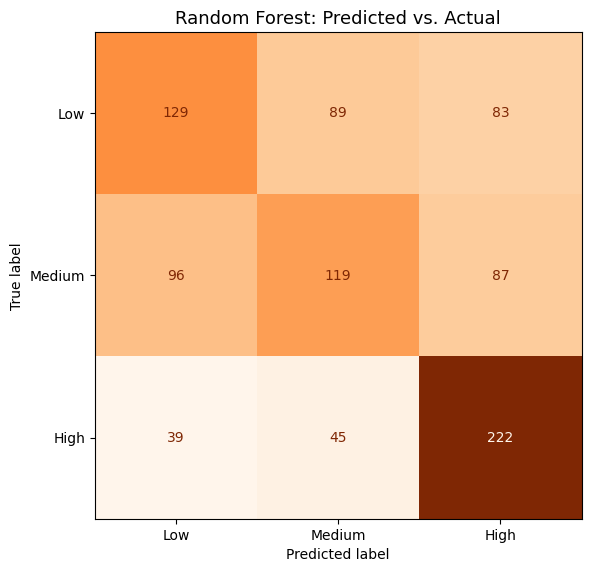

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=INTENSITY_ORDER, cmap="Oranges", ax=ax, colorbar=False)
ax.set_title("Random Forest: Predicted vs. Actual", fontsize=13)
plt.tight_layout()
plt.savefig("viz2_rf_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 3: What the Random Forest actually relies on

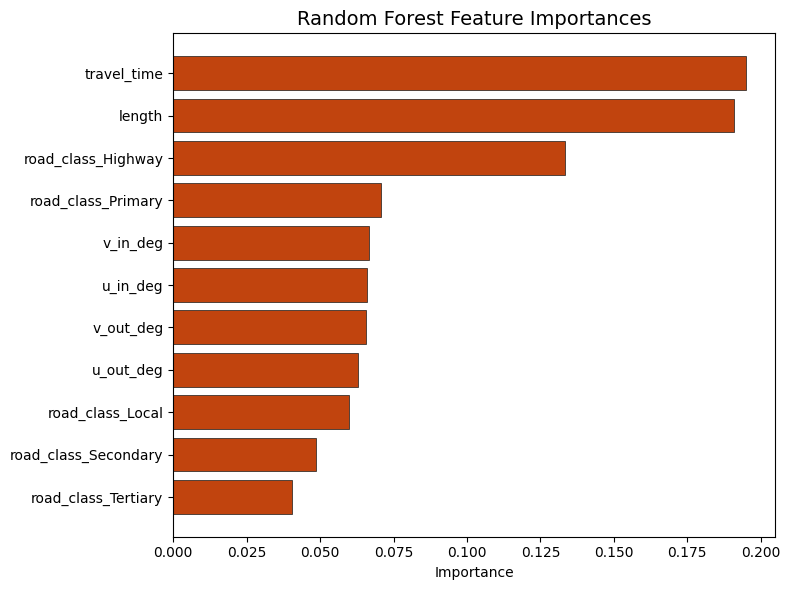

In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color="#c1440e", edgecolor=PGH_BLACK, linewidth=0.5)
ax.set_title("Random Forest Feature Importances", fontsize=14)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("viz3_rf_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 4: The light GNN

Architecture, in plain terms:
1. **Two GCN layers** learn a vector representation ("embedding") for every intersection in the *entire* network, using each intersection's neighbors -- including unlabeled roads. This is a real structural advantage over the Random Forest, which can only see labeled rows in isolation.
2. **A small road-class embedding table** (2 dimensions, so we can plot it directly later) replaces one-hot encoding for road class.
3. A final small network combines both intersection embeddings plus the road-class embedding plus length/travel-time to predict the intensity class for that segment.

In [13]:
edge_index = torch.tensor(merged[["u_idx", "v_idx"]].values.T, dtype=torch.long)

node_feat = np.zeros((len(node_ids), 2))
for idx, cnt in out_deg.items():
    node_feat[idx, 0] = cnt
for idx, cnt in in_deg.items():
    node_feat[idx, 1] = cnt
node_feat = np.log1p(node_feat)
x = torch.tensor(node_feat, dtype=torch.float)

class_list = sorted(merged["road_class"].unique())
class_to_idx = {c: i for i, c in enumerate(class_list)}
merged["class_idx"] = merged["road_class"].map(class_to_idx)

edge_class_idx = torch.tensor(merged["class_idx"].values, dtype=torch.long)
edge_u_idx = torch.tensor(merged["u_idx"].values, dtype=torch.long)
edge_v_idx = torch.tensor(merged["v_idx"].values, dtype=torch.long)

extra_raw = merged[["length", "travel_time"]].values.astype(np.float32)
extra_mean, extra_std = extra_raw.mean(axis=0), extra_raw.std(axis=0)
edge_extra_feats = torch.tensor((extra_raw - extra_mean) / extra_std, dtype=torch.float)

print(f"Nodes: {x.shape[0]:,}   Edges (all, for message passing): {edge_index.shape[1]:,}")


Nodes: 48,435   Edges (all, for message passing): 121,006


In [14]:
class RoadGNN(nn.Module):
    def __init__(self, num_node_feat=2, hidden_dim=16, num_classes=3, num_road_classes=5, class_embed_dim=2):
        super().__init__()
        self.conv1 = GCNConv(num_node_feat, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.class_embed = nn.Embedding(num_road_classes, class_embed_dim)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + class_embed_dim + 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, edge_index, edge_class_idx, edge_extra_feats, edge_u_idx, edge_v_idx):
        h = F.relu(self.conv1(x, edge_index))
        h = self.conv2(h, edge_index)
        class_emb = self.class_embed(edge_class_idx)
        edge_repr = torch.cat([h[edge_u_idx], h[edge_v_idx], class_emb, edge_extra_feats], dim=1)
        return self.edge_mlp(edge_repr), class_emb

model = RoadGNN(num_road_classes=len(class_list))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


In [15]:
train_mask = torch.zeros(len(merged), dtype=torch.bool)
test_mask = torch.zeros(len(merged), dtype=torch.bool)
train_mask[merged.index.isin(train_idx)] = True
test_mask[merged.index.isin(test_idx)] = True

y_full = torch.zeros(len(merged), dtype=torch.long)
y_full[labeled.index] = torch.tensor(labeled["label"].values, dtype=torch.long)

EPOCHS = 150
losses = []

model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    out, _ = model(x, edge_index, edge_class_idx, edge_extra_feats, edge_u_idx, edge_v_idx)
    loss = F.cross_entropy(out[train_mask], y_full[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"Epoch {epoch:3d}   loss = {loss.item():.4f}")

print(f"Final loss: {losses[-1]:.4f}")


Epoch   0   loss = 1.1198
Epoch  25   loss = 0.9742
Epoch  50   loss = 0.9596
Epoch  75   loss = 0.9569
Epoch 100   loss = 0.9549
Epoch 125   loss = 0.9528
Final loss: 0.9508


## Visual 4: GNN training loss

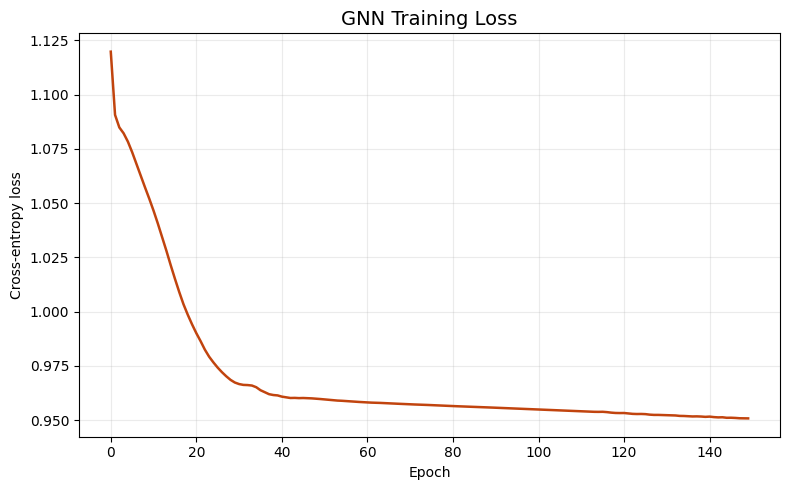

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses, color="#c1440e", linewidth=1.8)
ax.set_title("GNN Training Loss", fontsize=14)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("viz4_gnn_training_loss.png", dpi=200, bbox_inches="tight")
plt.show()


In [17]:
model.eval()
with torch.no_grad():
    out, class_emb = model(x, edge_index, edge_class_idx, edge_extra_feats, edge_u_idx, edge_v_idx)
    gnn_pred_all = out.argmax(dim=1)

gnn_pred_test = gnn_pred_all[test_mask].numpy()
y_test_gnn = y_full[test_mask].numpy()

gnn_acc = accuracy_score(y_test_gnn, gnn_pred_test)
gnn_f1 = f1_score(y_test_gnn, gnn_pred_test, average="macro")
print(f"GNN -- accuracy: {gnn_acc:.3f}   macro F1: {gnn_f1:.3f}")
print(f"Random Forest -- accuracy: {rf_acc:.3f}   macro F1: {rf_f1:.3f}")


GNN -- accuracy: 0.528   macro F1: 0.512
Random Forest -- accuracy: 0.517   macro F1: 0.507


## Visual 5: GNN confusion matrix

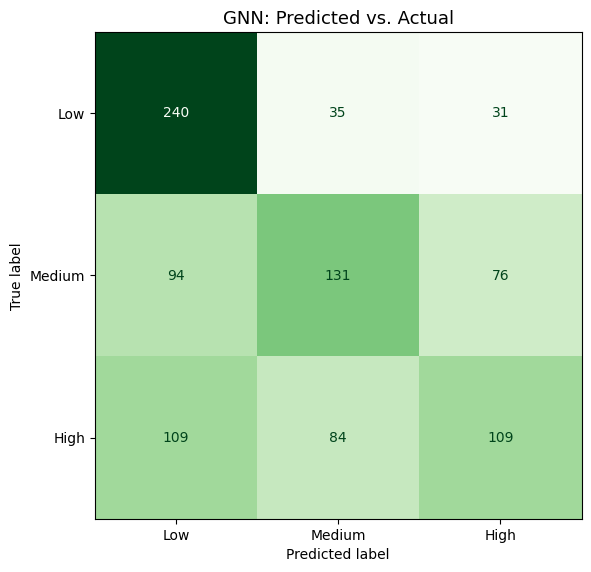

In [18]:
inv_label_map = {v: k for k, v in label_map.items()}
y_test_gnn_labels = [inv_label_map[i] for i in y_test_gnn]
gnn_pred_labels = [inv_label_map[i] for i in gnn_pred_test]

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test_gnn_labels, gnn_pred_labels, display_labels=INTENSITY_ORDER, cmap="Greens", ax=ax, colorbar=False)
ax.set_title("GNN: Predicted vs. Actual", fontsize=13)
plt.tight_layout()
plt.savefig("viz5_gnn_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 6: Head-to-head comparison

Worth reporting honestly either way -- if the GNN doesn't win by much on this simple task, that's a legitimate finding, not a failure. The point of this project is the mechanism, not a guaranteed win.

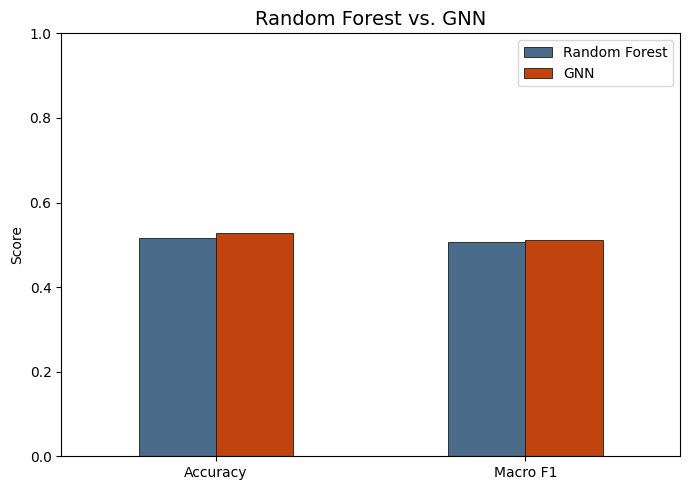

          Random Forest       GNN
Accuracy       0.517052  0.528053
Macro F1       0.507190  0.512401


In [19]:
comparison = pd.DataFrame({
    "Random Forest": [rf_acc, rf_f1],
    "GNN": [gnn_acc, gnn_f1],
}, index=["Accuracy", "Macro F1"])

fig, ax = plt.subplots(figsize=(7, 5))
comparison.plot(kind="bar", ax=ax, color=["#4a6b8a", "#c1440e"], edgecolor=PGH_BLACK, linewidth=0.6)
ax.set_title("Random Forest vs. GNN", fontsize=14)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title=None)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("viz6_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print(comparison)


## Visual 7: What the GNN actually learned about road classes

This is the payoff. We set the road-class embedding to exactly 2 dimensions, so we can plot the model's internal representation directly -- no dimensionality reduction needed. Classes that end up close together are ones the model has learned to treat similarly; classes far apart are ones it's learned to treat very differently. Compare this to a one-hot encoding, where every class would sit at an equal, arbitrary distance from every other class regardless of what the data actually shows.

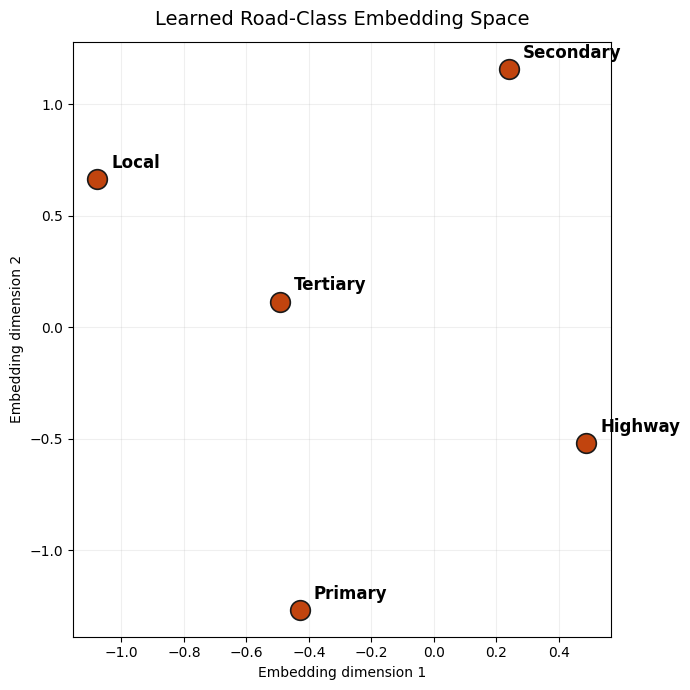

In [20]:
class_emb_np = model.class_embed.weight.detach().numpy()

fig, ax = plt.subplots(figsize=(7, 7))
for i, cls in enumerate(class_list):
    ax.scatter(class_emb_np[i, 0], class_emb_np[i, 1], s=200, color="#c1440e", edgecolor=PGH_BLACK, linewidth=1.2, zorder=3)
    ax.annotate(cls, (class_emb_np[i, 0], class_emb_np[i, 1]), textcoords="offset points", xytext=(10, 8), fontsize=12, fontweight="bold")

ax.set_title("Learned Road-Class Embedding Space", fontsize=14, pad=12)
ax.set_xlabel("Embedding dimension 1")
ax.set_ylabel("Embedding dimension 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("viz7_learned_class_embedding.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 8: Where each model gets it wrong — mapped

Same real-basemap treatment as Projects 1-2. Correctly classified test segments in gray, misclassified ones highlighted, so you can see whether errors cluster somewhere specific (e.g., ambiguous mid-hierarchy roads) or scatter randomly.

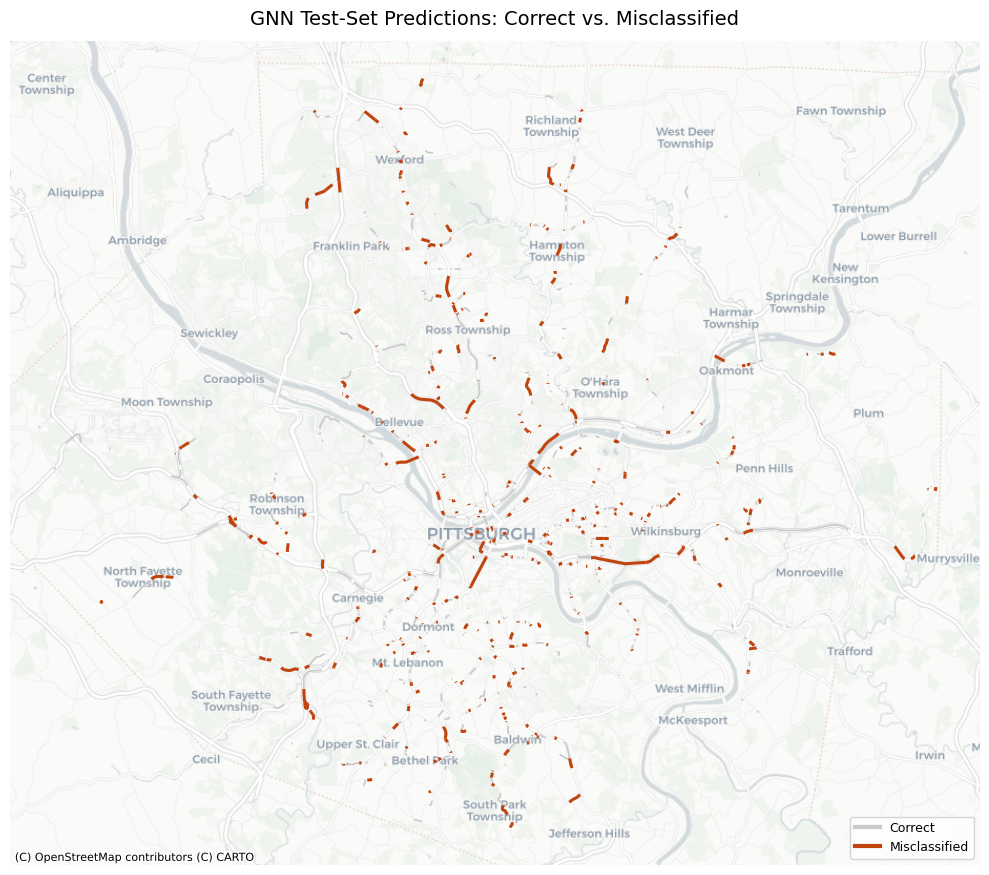

In [21]:
test_segments = merged.loc[test_idx].copy()
test_segments["actual_label"] = [inv_label_map[i] for i in y_test_gnn]
test_segments["gnn_pred_label"] = gnn_pred_labels
test_segments["rf_pred_label"] = [inv_label_map[i] for i in rf_pred]
test_segments["gnn_correct"] = test_segments["actual_label"] == test_segments["gnn_pred_label"]

test_3857 = test_segments.set_geometry("geometry").set_crs(G_crs).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
test_3857[test_3857["gnn_correct"]].plot(ax=ax, color="#c9c9c9", linewidth=1.2, zorder=2, label="Correct")
test_3857[~test_3857["gnn_correct"]].plot(ax=ax, color="#c1440e", linewidth=2.2, zorder=3, label="Misclassified")

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=0)

handles = [plt.Line2D([0], [0], color="#c9c9c9", linewidth=3, label="Correct"),
           plt.Line2D([0], [0], color="#c1440e", linewidth=3, label="Misclassified")]
ax.legend(handles=handles, loc="lower right", fontsize=9)
ax.set_title("GNN Test-Set Predictions: Correct vs. Misclassified", fontsize=14, pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("viz8_gnn_errors_map.png", dpi=200, bbox_inches="tight")
plt.show()


## Save everything

In [22]:
from google.colab import files

viz_files = [
    "viz1_class_balance.png",
    "viz2_rf_confusion_matrix.png",
    "viz3_rf_feature_importance.png",
    "viz4_gnn_training_loss.png",
    "viz5_gnn_confusion_matrix.png",
    "viz6_model_comparison.png",
    "viz7_learned_class_embedding.png",
    "viz8_gnn_errors_map.png",
]
for f in viz_files:
    files.download(f)

comparison.to_csv("pittsburgh_model_comparison.csv")
files.download("pittsburgh_model_comparison.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just:
- Built a fair, identical-split comparison between a tabular baseline and a graph-aware model
- Watched the road-class encoding question from a few weeks back resolve itself -- the model learned its own 2D representation of road-class relationships, which you can now literally see in Visual 7
- Got 8 visuals to choose from for the newsletter, spanning class balance, both models' errors, the head-to-head comparison, the training curve, and a geospatial error map

**Project 4** builds the live simulation next -- streetlights and traffic flow as a running system, built on the same road/intersection graph, setting up the ground this GNN's decision-making cousin will operate on in Project 5.